In [1]:
import pandas as pd

df_vagas = pd.read_parquet('../data/processed/vagas_cursos_tratados.parquet')
df_matriculas = pd.read_parquet('../data/processed/microdados_matriculas_tratados.parquet')

In [2]:
df_vagas.head(10)

,codigo_ciclo_matricula,vagas_regulares_l1,vagas_regulares_l2,vagas_regulares_l5,vagas_regulares_l6,vagas_regulares_l9,vagas_regulares_ac
0,802715,0,0,0,0,0,40
1,805360,1,7,1,7,1,20
2,805366,1,6,1,5,0,14
3,1209276,2,6,2,10,0,20
4,1209283,2,6,2,10,0,20
5,1209717,1,7,1,7,1,20
6,1251999,0,0,0,0,0,40
7,1254683,2,4,2,4,0,15
8,1255338,1,6,1,5,0,14
9,1255340,1,6,1,5,0,14


**Tratamento de valores ausentes**

In [12]:
# Detectar valores ausentes
df_vagas.isna().sum()

codigo_ciclo_matricula    0
vagas_regulares_l1        0
vagas_regulares_l2        0
vagas_regulares_l5        0
vagas_regulares_l6        0
vagas_regulares_l9        0
vagas_regulares_ac        0
dtype: int64

In [15]:
# Identificar as colunas de vagas dinamicamente, excluindo a chave do curso
colunas_vagas = df_vagas.columns.difference(['codigo_ciclo_matricula']).tolist()

# Substituir os valores nulos estruturais (<NA>) por 0 em bloco
df_vagas[colunas_vagas] = df_vagas[colunas_vagas].fillna(0)

In [16]:
df_vagas.describe()

,vagas_regulares_l1,vagas_regulares_l2,vagas_regulares_l5,vagas_regulares_l6,vagas_regulares_l9,vagas_regulares_ac
count,599.0,599.0,599.0,599.0,599.0,599.0
mean,1.542571,6.657763,1.524207,6.42404,0.292154,18.777963
std,1.106884,4.055807,1.256022,4.114639,0.731372,14.122699
min,0.0,0.0,0.0,0.0,0.0,0.0
25%,1.0,6.0,1.0,5.0,0.0,15.0
50%,2.0,7.0,1.0,7.0,0.0,19.0
75%,2.0,7.0,2.0,7.0,0.0,20.0
max,14.0,56.0,17.0,56.0,8.0,204.0


**Dicionário de Termos e Critérios da Lei de Cotas (Lei nº 12.711/2012)**

Para interpretar a distribuição estatística das vagas ofertadas, os códigos das colunas devem ser associados aos critérios regulamentares de reserva de vagas no Ensino Superior Federal:

* **`vagas_regulares_ac` (Ampla Concorrência):** Vagas universais, abertas a qualquer candidato sem exigência de critérios socioeconômicos ou demográficos.
* **`vagas_regulares_l1` (Cota L1):** Vagas reservadas a estudantes que cursaram integralmente o Ensino Médio em **Escola Pública** e possuem renda familiar per capita de **baixa renda** (até 1 salário mínimo).
* **`vagas_regulares_l2` (Cota L2):** Vagas reservadas a estudantes de **Escola Pública**, de **Baixa Renda**, autodeclarados **Pretos, Pardos ou Indígenas (PPI)**.
* **`vagas_regulares_l5` (Cota L5):** Vagas reservadas a estudantes de **Escola Pública**, com **Renda Livre** (sem necessidade de comprovação de renda).
* **`vagas_regulares_l6` (Cota L6):** Vagas reservadas a estudantes de **Escola Pública**, de **Renda Livre**, autodeclarados **Pretos, Pardos ou Indígenas (PPI)**.
* **`vagas_regulares_l9` (Cota L9):** Vagas reservadas a estudantes de **Escola Pública**, de **Baixa Renda** e que sejam **Pessoas com Deficiência (PCD)**.

> **Regra de Proporcionalidade:** Os recortes raciais (PPI) e de deficiência (PCD) aplicados nas cotas pares (`L2`, `L6`) e nas cotas de inclusão especial (`L9`) seguem estritamente a proporção demográfica dessas populações no estado da Bahia, com base nos dados oficiais do censo do IBGE.


In [6]:
# Visualizar cursos com recordes de distribuição de vagas
# Identificar as colunas de vagas dinamicamente (usando a lista existente ou filtrando)
colunas_vagas = df_vagas.columns.difference(['codigo_ciclo_matricula', 'unidade_ensino', 'total_alunos_curso']).tolist()

# Capturar o índice (index) onde ocorre o valor máximo de cada coluna de vagas
indices_recordistas = [df_vagas[col].idxmax() for col in colunas_vagas]

# Remover índices duplicados (caso um único curso detenha o recorde de mais de uma coluna)
indices_unicos = list(set(indices_recordistas))

# Filtrar o DataFrame original usando esses índices e ordenar para melhor leitura
df_recordistas = df_vagas.loc[indices_unicos].sort_index()

print("=== TABELA CONSOLIDADA DE CURSOS RECORDISTAS EM OFERTA DE VAGAS ===")
display(df_recordistas)


=== TABELA CONSOLIDADA DE CURSOS RECORDISTAS EM OFERTA DE VAGAS ===


,codigo_ciclo_matricula,vagas_regulares_l1,vagas_regulares_l2,vagas_regulares_l5,vagas_regulares_l6,vagas_regulares_l9,vagas_regulares_ac
19,1722435,0,0,17,0,0,20
181,2438898,14,49,14,49,2,204
441,2730239,8,56,8,56,8,166


In [18]:
# Criar uma lista com os três códigos recordistas
codigos_recordistas = df_recordistas['codigo_ciclo_matricula'].astype(str).tolist()
# Extrair os dados cadastrais únicos a partir do DataFrame principal
df_nomes_cursos = df_matriculas[['codigo_ciclo_matricula', 'nome_curso', 'unidade_ensino']].drop_duplicates(subset=['codigo_ciclo_matricula'])

# Filtrar e exibir os dados cadastrais dos recordistas
dados_identificados = df_nomes_cursos[df_nomes_cursos['codigo_ciclo_matricula'].isin(codigos_recordistas)]
display(dados_identificados)

,codigo_ciclo_matricula,nome_curso,unidade_ensino
24,1722435,Matemática,Campus Camaçari
969,2438898,Física,Campus Salvador
5880,2730239,Administração,Campus Ilhéus


In [8]:
# Aplicar média ponderada para visualizar a distribuição de vagas por unidade de ensino, considerando os pesos
import numpy as np

# Contar quantidade de alunos em cada curso direto do df_matriculas
pesos_curso = df_matriculas['codigo_ciclo_matricula'].value_counts().reset_index()
pesos_curso.columns = ['codigo_ciclo_matricula', 'total_alunos_curso']

# Extrair a relação única entre o curso e a unidade de ensino (campus)
df_campus_curso = df_matriculas[['codigo_ciclo_matricula', 'unidade_ensino']].drop_duplicates()

# Trazer o peso de alunos e a unidade de ensino para a tabela de vagas
df_vagas_ponderado = pd.merge(df_vagas, pesos_curso, on='codigo_ciclo_matricula', how='left')
df_vagas_ponderado = pd.merge(df_vagas_ponderado, df_campus_curso, on='codigo_ciclo_matricula', how='left')

# Definir a função para calcular a média ponderada ignorando valores nulos (NaN)
def media_ponderada(group, col_vagas):
    # 1. Isolar apenas as linhas que possuem números válidos tanto na coluna de vagas quanto no peso
    dados_validos = group.dropna(subset=[col_vagas, 'total_alunos_curso'])
    
    vagas = dados_validos[col_vagas]
    pesos = dados_validos['total_alunos_curso']
    
    # 2. Verificar se sobrou algum dado válido ou se a soma dos pesos é zero
    if len(dados_validos) == 0 or pesos.sum() == 0:
        return np.nan # Retornamos NaN (em vez de 0) para o gráfico não interpretar como "zero vagas"
        
    # 3. Calcular a média ponderada apenas com os dados limpos
    return np.average(vagas, weights=pesos)

# Executar o groupby aplicando a média ponderada para cada coluna
colunas_vagas = df_vagas_ponderado.columns.difference(['codigo_ciclo_matricula', 'unidade_ensino', 'total_alunos_curso']).tolist()

analise_ponderada = df_vagas_ponderado.groupby('unidade_ensino').apply(
    lambda g: pd.Series({col: media_ponderada(g, col) for col in colunas_vagas}),
    include_groups=False 
).round(1)

# Exibir o resultado final ordenado pela Ampla Concorrência (AC)
print("Média Ponderada de Vagas (Peso: Volume de Alunos Matriculados por Curso):")
display(analise_ponderada.sort_values(by='vagas_regulares_ac', ascending=False))

Média Ponderada de Vagas (Peso: Volume de Alunos Matriculados por Curso):


,vagas_regulares_ac,vagas_regulares_l1,vagas_regulares_l2,vagas_regulares_l5,vagas_regulares_l6,vagas_regulares_l9
unidade_ensino,,,,,,
Campus Ilhéus,150.7,7.3,50.8,7.3,50.8,7.2
Campus Santo Amaro,54.4,3.9,14.4,4.0,14.2,0.3
Campus Porto Seguro,25.5,1.3,5.6,1.3,5.2,0.3
Campus Brumado,23.0,2.0,4.7,0.5,4.1,0.0
Campus Lauro de Freitas,22.5,2.6,8.2,1.8,8.2,0.0
Campus Avançado Ubaitaba,22.0,2.0,8.0,2.0,8.0,2.0
Campus Feira de Santana,20.6,1.5,6.9,1.5,6.9,0.4
Campus Seabra,20.0,2.0,6.0,2.0,6.0,1.0
Campus Vitória da Conquista,20.0,2.1,7.4,1.9,7.3,0.5


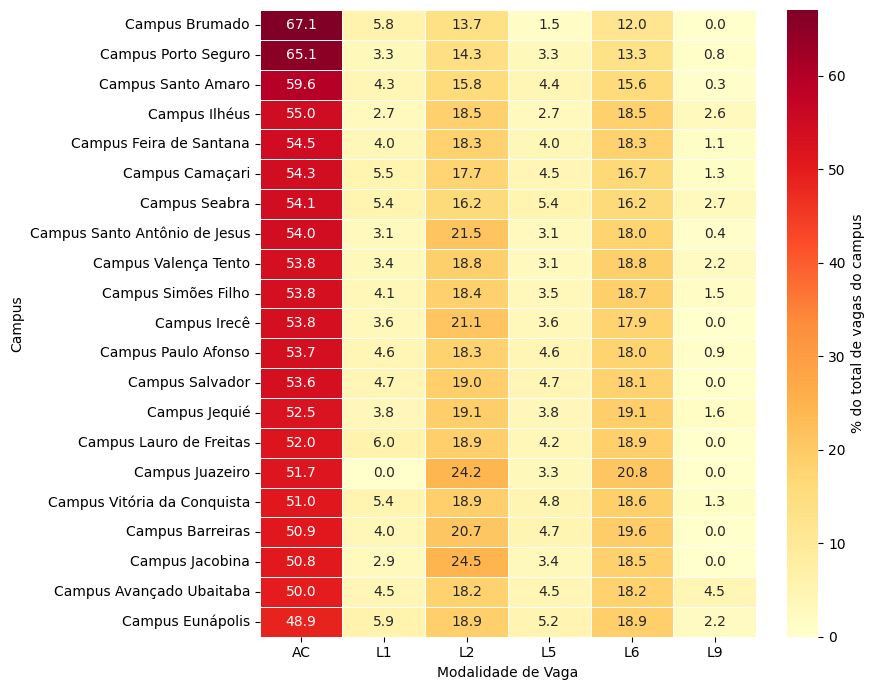

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# Normalizar cada linha para percentual (composição proporcional por campus)
# Evita que vagas_regulares_ac domine a escala de cor
heatmap_data = analise_ponderada.copy()
heatmap_data = heatmap_data.div(heatmap_data.sum(axis=1), axis=0) * 100

# Renomear colunas para rótulos curtos e legíveis
heatmap_data.columns = ['AC', 'L1', 'L2', 'L5', 'L6', 'L9']
heatmap_data.index.name = 'Campus'

# Ordenar por proporção de Ampla Concorrência (decrescente)
heatmap_data = heatmap_data.sort_values(by='AC', ascending=False)

plt.figure(figsize=(9, 7))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': '% do total de vagas do campus'}
)
#plt.title('Composição Proporcional da Oferta de Vagas por Campus (%)')
plt.xlabel('Modalidade de Vaga')
plt.tight_layout()
plt.show()


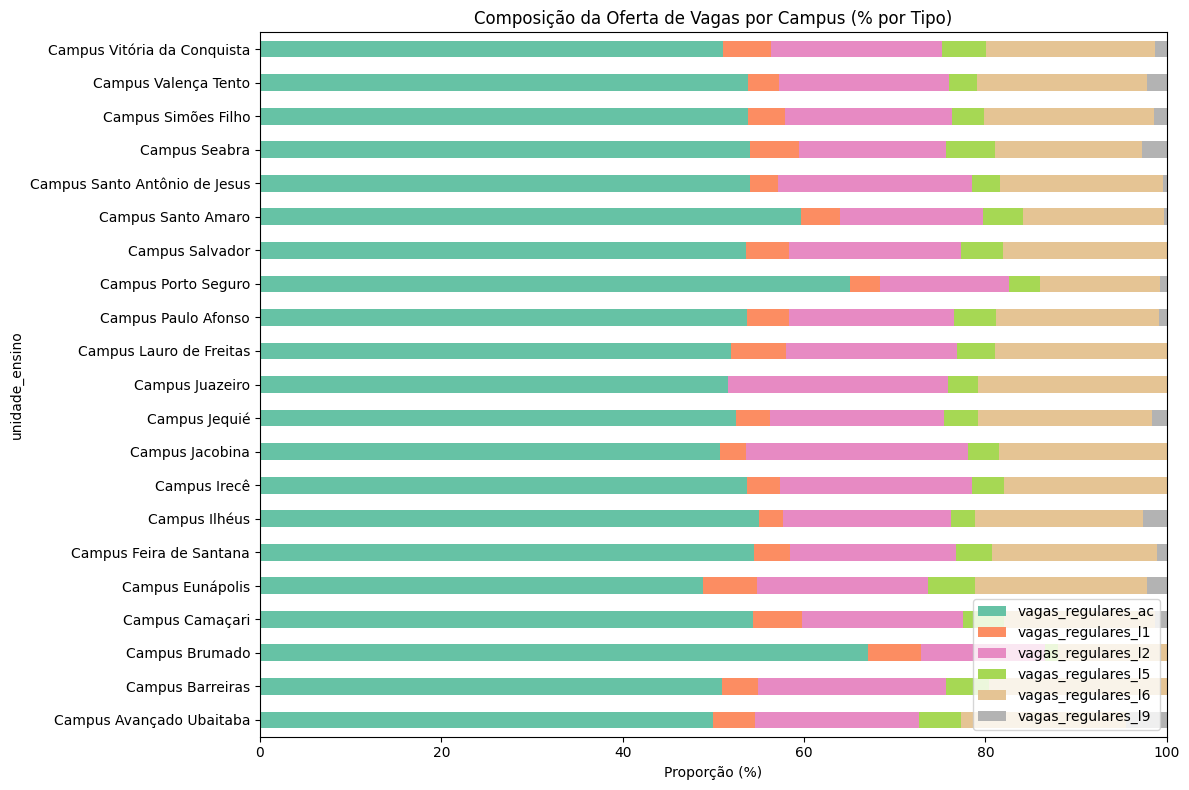

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

analise_perc = analise_ponderada.copy()
analise_perc['total'] = analise_perc.sum(axis=1)
for col in colunas_vagas:
    analise_perc[col] = analise_perc[col] / analise_perc['total'] * 100

analise_perc[colunas_vagas].plot(
    kind='barh', stacked=True, figsize=(12, 8),
    colormap='Set2'
)
plt.xlabel('Proporção (%)')
plt.title('Composição da Oferta de Vagas por Campus (% por Tipo)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

A observação de médias ponderadas iguais a zero para a cota L9 em campi consolidados (como Salvador e Barreiras) não sinaliza descumprimento da Lei nº 12.711/2012, mas sim o efeito de tangência ao zero por arredondamento normativo:

- O percentual de PCD determinado pelo IBGE para o estado da Bahia, quando aplicado sobre subgrupos de renda em turmas de tamanho padrão (30 a 40 vagas totais), resulta em frações estritamente menores que 0,5 vagas por curso. Seguindo as normativas de editais unificados, esses valores sofrem arredondamento para zero.
- Para garantir a reserva legal global, a instituição adota a estratégia de centralização, acumulando as frações de direito em macrociclos específicos de alta densidade (como o Campus Ilhéus, que absorve o teto de 7,2 vagas ponderadas na categoria), gerando uma distribuição espacial heterogênea, porém legalmente assistida.


In [9]:
# Filtrar a base para conter apenas os dados de vagas do Campus Salvador
df_salvador_vagas = df_vagas_ponderado[df_vagas_ponderado['unidade_ensino'] == 'Campus Salvador']

# Contar quantos editais de cursos tiveram ZERO vagas para L9 e quantos tiveram > 0
total_cursos_salvador = len(df_salvador_vagas)
zeros_l9 = (df_salvador_vagas['vagas_regulares_l9'] == 0).sum()
maior_que_zero_l9 = (df_salvador_vagas['vagas_regulares_l9'] > 0).sum()

print(f"=== DIAGNÓSTICO DA COTA L9 NO CAMPUS SALVADOR ===")
print(f"Total de cursos/ciclos avaliados no campus: {total_cursos_salvador}")
print(f"Quantidade de cursos com ZERO vagas para L9: {zeros_l9} ({zeros_l9/total_cursos_salvador*100:.1f}%)")
print(f"Quantidade de cursos com alguma vaga para L9: {maior_que_zero_l9} ({maior_que_zero_l9/total_cursos_salvador*100:.1f}%)")

# Se houver algum curso com vagas > 0, vamos ver quais são eles e quantas vagas tinham
if maior_que_zero_l9 > 0:
    print("\nCursos em Salvador que conseguiram abrir vagas para L9:")
    display(df_salvador_vagas[df_salvador_vagas['vagas_regulares_l9'] > 0][['codigo_ciclo_matricula', 'vagas_regulares_l9', 'total_alunos_curso']])


=== DIAGNÓSTICO DA COTA L9 NO CAMPUS SALVADOR ===
Total de cursos/ciclos avaliados no campus: 174
Quantidade de cursos com ZERO vagas para L9: 169 (97.1%)
Quantidade de cursos com alguma vaga para L9: 5 (2.9%)

Cursos em Salvador que conseguiram abrir vagas para L9:


,codigo_ciclo_matricula,vagas_regulares_l9,total_alunos_curso
17,1602825,1,3
180,2438677,1,14
181,2438898,2,20
212,2500969,1,23
376,2742911,1,50


In [ ]:
# Gerar a contagem definitiva de ciclos unicos (cursos) por unidade de ensino
contagem_cursos_final = df_vagas_ponderado['unidade_ensino'].value_counts()

# Renomear as colunas para o formato legivel de relatorio
contagem_cursos_final.index.name = 'Unidade de Ensino (Campus)'
contagem_cursos_final.name = 'Quantidade de Cursos/Ciclos'

# Exibir a tabela descritiva estruturada
print("=== ESTRUTURA RELACIONAL: DISTRIBUIÇÃO DE CURSOS POR CAMPUS ===")
display(contagem_cursos_final)


=== ESTRUTURA RELACIONAL: DISTRIBUIÇÃO DE CURSOS EXCLUSIVOS POR CAMPUS ===


Unidade de Ensino (Campus)
Campus Salvador                  174
Campus Vitória da Conquista       75
Campus Porto Seguro               49
Campus Valença Tento              37
Campus Santo Antônio de Jesus     31
Campus Barreiras                  27
Campus Eunápolis                  27
Campus Camaçari                   25
Campus Irecê                      25
Campus Paulo Afonso               24
Campus Simões Filho               22
Campus Santo Amaro                21
Campus Lauro de Freitas           18
Campus Feira de Santana           13
Campus Jequié                      9
Campus Jacobina                    8
Campus Brumado                     6
Campus Ilhéus                      3
Campus Avançado Ubaitaba           2
Campus Juazeiro                    2
Campus Seabra                      1
Name: Quantidade de Cursos/Ciclos, dtype: int64